In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

In [2]:
# Parameters (arbitrary)
S0 = 100.0      # initial stock price
K = 100.0       # strike price
r = 0.05        # risk-free rate
sigma = 0.2     # volatility
T = 1.0         # time to maturity (in years)
n_steps = 252   # number of time steps
n_paths = 10000 # number of Monte Carlo paths

dt = T / n_steps

# Simulate asset paths under risk-neutral measure (GBM)
# S_{t+dt} = S_t * exp((r - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
Z = np.random.normal(size=(n_paths, n_steps))
increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
log_S = np.log(S0) + np.cumsum(increments, axis=1)
S_paths = np.exp(log_S)

# Extract terminal prices
S_T = S_paths[:, -1]

# European call payoff
payoffs = np.maximum(S_T - K, 0.0)

# Discounted Monte Carlo price
mc_price = np.exp(-r * T) * np.mean(payoffs)
std_error = np.exp(-r * T) * np.std(payoffs) / np.sqrt(n_paths)

print(f"Monte Carlo European call price: {mc_price:.4f} ± {1.96*std_error:.4f} (95% CI)")

Monte Carlo European call price: 10.7560 ± 0.2946 (95% CI)


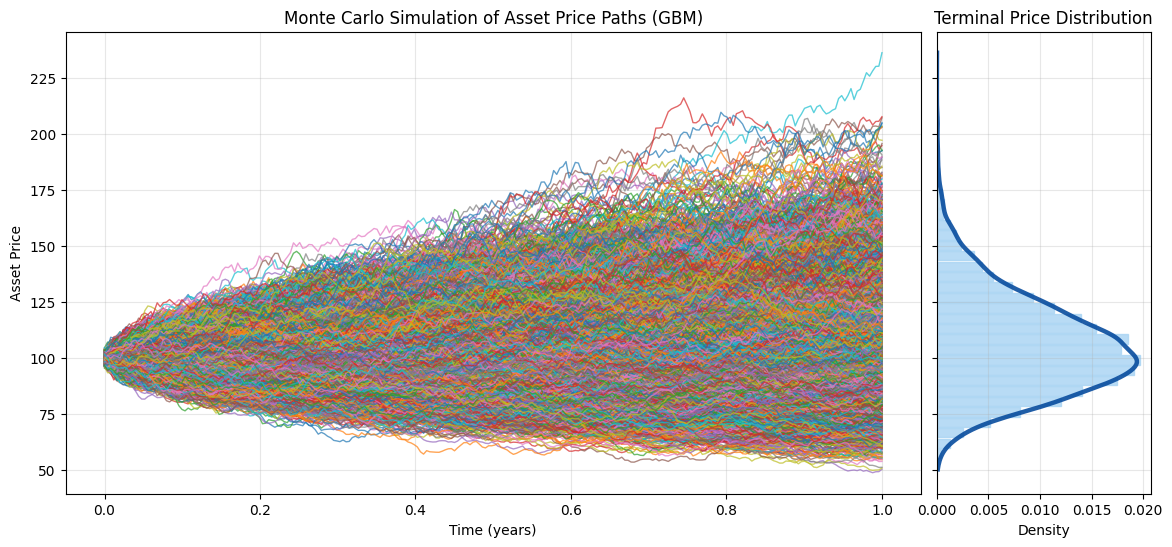

In [11]:
# Plot a subset of the simulated paths for visualization
n_plot_paths = 10000
time_grid = np.linspace(0, T, n_steps)

plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.03)

# left: GBM simulation (unchanged)
ax_paths = plt.subplot(gs[0])
for i in range(n_plot_paths):
    ax_paths.plot(time_grid, S_paths[i], linewidth=1, alpha=0.7)

ax_paths.set_title("Monte Carlo Simulation of Asset Price Paths (GBM)")
ax_paths.set_xlabel("Time (years)")
ax_paths.set_ylabel("Asset Price")
ax_paths.grid(True, alpha=0.3)

# right: histogram + KDE
ax_hist = plt.subplot(gs[1], sharey=ax_paths)

counts, edges = np.histogram(S_T, bins=40, density=True)
centers = (edges[:-1] + edges[1:]) / 2
bin_width = edges[1] - edges[0]

# histogram with stronger but still soft color
ax_hist.barh(
    centers,
    counts,
    height=bin_width * 0.9,
    color="#A7D3F3",        # slightly deeper light-blue
    alpha=0.8,
    edgecolor="#A7D3F3"
)

kde = gaussian_kde(S_T)
y_vals = np.linspace(min(S_T), max(S_T), 200)
x_vals = kde(y_vals)

# KDE: clearer contrast, deep royal-blue
ax_hist.plot(
    x_vals,
    y_vals,
    color="#084C9E",        # strong blue with good contrast
    linewidth=3.2,
    alpha=0.9               # slightly less transparent
)

ax_hist.set_title("Terminal Price Distribution")
ax_hist.set_xlabel("Density")

ax_hist.set_ylabel("")
ax_hist.tick_params(axis="y", labelleft=False)

ax_hist.grid(True, alpha=0.3)
ax_hist.set_ylim(ax_paths.get_ylim())

# use constrained_layout instead of tight_layout to avoid warning
plt.gcf().set_constrained_layout_pads(w_pad=0.02, h_pad=0.02)
plt.show()

In [4]:
# Black–Scholes European call price (on S0, K, r, sigma, T already defined)
d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
d2 = d1 - sigma * sqrt(T)

bs_call_price = S0 * norm.cdf(d1) - K * exp(-r * T) * norm.cdf(d2)
print(f"Black–Scholes European call price: {bs_call_price:.4f}")

Black–Scholes European call price: 10.4506


In [5]:
# Binomial (CRR) pricing with tree construction and plotting
N = n_steps
dt_b = T / N

u = np.exp(sigma * np.sqrt(dt_b))
d = 1.0 / u
p = (np.exp(r * dt_b) - d) / (u - d)
disc = np.exp(-r * dt_b)

# Build stock price tree (upper triangular matrix)
S_tree = np.zeros((N + 1, N + 1))
for i in range(N + 1):
    for j in range(i + 1):
        S_tree[i, j] = S0 * (u ** j) * (d ** (i - j))

# Terminal payoff
C_tree = np.maximum(S_tree[N, :N + 1] - K, 0.0)

# Backward induction
for i in range(N - 1, -1, -1):
    C_next = np.zeros(i + 1)
    for j in range(i + 1):
        C_next[j] = disc * (p * C_tree[j + 1] + (1.0 - p) * C_tree[j])
    C_tree = C_next

binom_price = C_tree[0]
print(f"Binomial (CRR, N={N}) European call price: {binom_price:.4f}")

Binomial (CRR, N=252) European call price: 10.4427


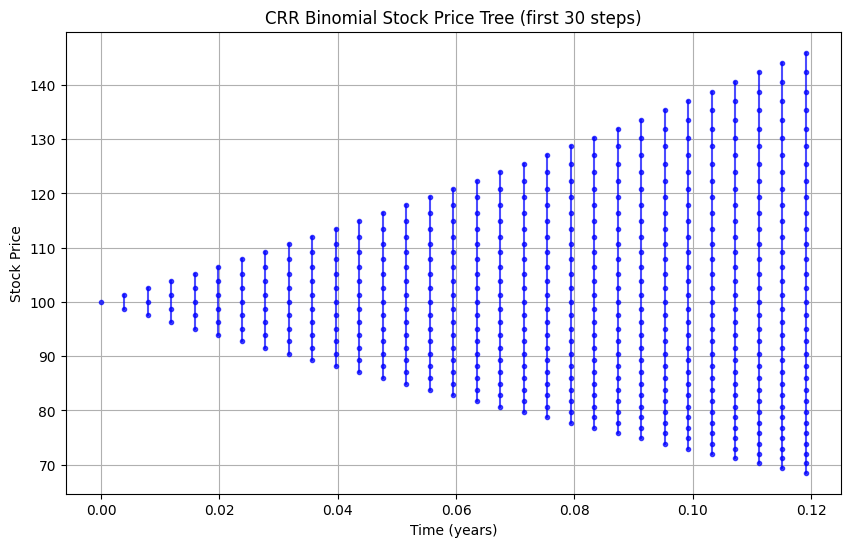

In [6]:
# Plot a slice of the binomial tree (first 30 steps)
max_plot_steps = 30
steps_to_plot = min(N, max_plot_steps)

plt.figure(figsize=(10, 6))
for i in range(steps_to_plot + 1):
    x_vals = np.full(i + 1, i * dt_b)
    y_vals = S_tree[i, :i + 1]
    plt.plot(x_vals, y_vals, 'bo-', markersize=3, alpha=0.7)

plt.title("CRR Binomial Stock Price Tree (first 30 steps)")
plt.xlabel("Time (years)")
plt.ylabel("Stock Price")
plt.grid(True)
plt.show()

---

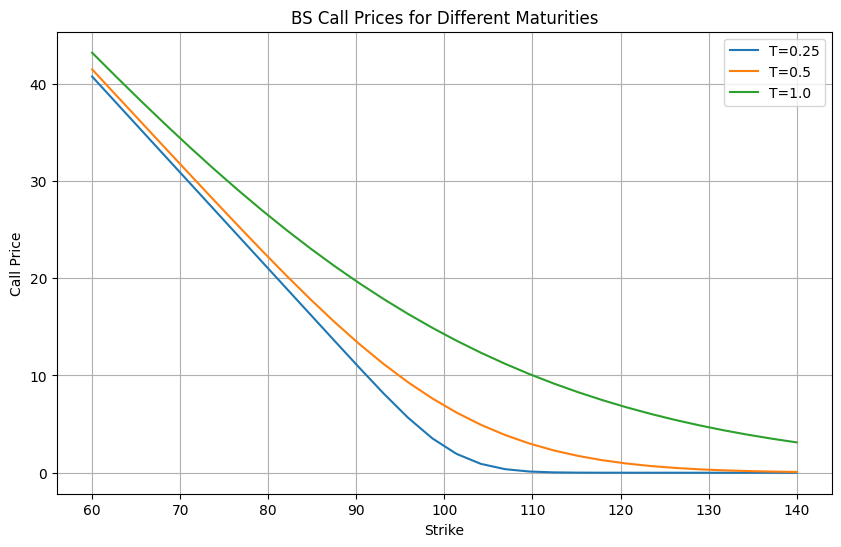

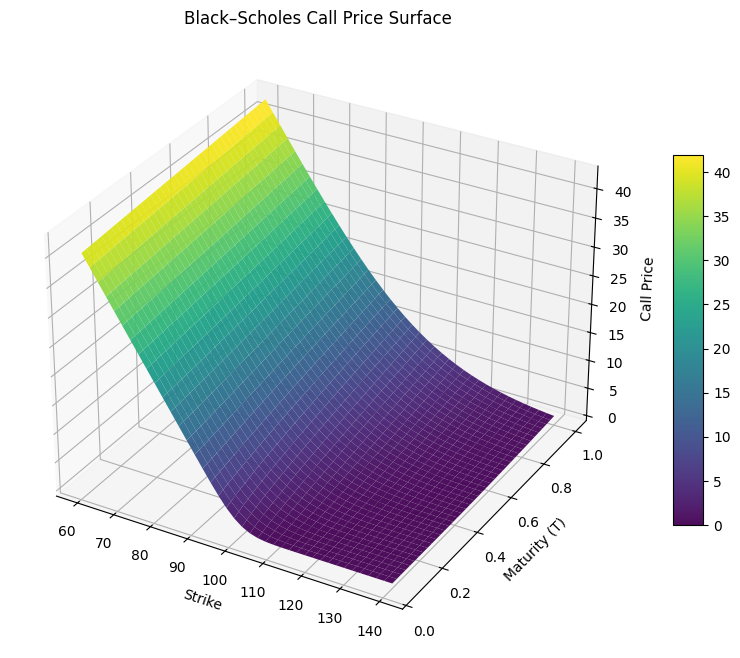

In [7]:
# BS function for call price
def my_bs_call_price(spot, strike, rate, vol, tau):
    d1 = (np.log(spot / strike) + (rate + 0.5 * vol**2) * tau) / (vol * np.sqrt(tau))
    d2 = d1 - vol * np.sqrt(tau)
    return spot * norm.cdf(d1) - strike * np.exp(-rate * tau) * norm.cdf(d2)

# strike smile lines
strike_values = np.linspace(60, 140, 30)
tau_values = [0.25, 0.5, 1.0]
vol_values = [0.1, 0.2, 0.3]

plt.figure(figsize=(10, 6))

for tau, vol in zip(tau_values, vol_values):
    call_values = [my_bs_call_price(S0, strike, r, vol, tau) for strike in strike_values]
    plt.plot(strike_values, call_values, label=f"T={tau}")

plt.title("BS Call Prices for Different Maturities")
plt.xlabel("Strike")
plt.ylabel("Call Price")
plt.grid(True)
plt.legend()
plt.show()

# 3D price surface
strike_grid = np.linspace(60, 140, 40)
tau_grid = np.linspace(0.05, 1.0, 40)

strike_mesh, tau_mesh = np.meshgrid(strike_grid, tau_grid)
price_mesh = my_bs_call_price(S0, strike_mesh, r, sigma, tau_mesh)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    strike_mesh,
    tau_mesh,
    price_mesh,
    cmap="viridis",          # colour map for the surface
    linewidth=0,
    antialiased=True,
    alpha=0.95
)

fig.colorbar(surface, shrink=0.6, aspect=12)

ax.set_title("Black–Scholes Call Price Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (T)")
ax.set_zlabel("Call Price")

plt.show()

---

In [8]:
def my_bs_delta(spot, strike, rate, vol, tau):
    d1 = (np.log(spot/strike) + (rate + 0.5*vol**2)*tau) / (vol*np.sqrt(tau))
    return norm.cdf(d1)

def my_bs_gamma(spot, strike, rate, vol, tau):
    d1 = (np.log(spot/strike) + (rate + 0.5*vol**2)*tau) / (vol*np.sqrt(tau))
    return norm.pdf(d1) / (spot * vol * np.sqrt(tau))

def my_bs_vega(spot, strike, rate, vol, tau):
    d1 = (np.log(spot/strike) + (rate + 0.5*vol**2)*tau) / (vol*np.sqrt(tau))
    return spot * norm.pdf(d1) * np.sqrt(tau)

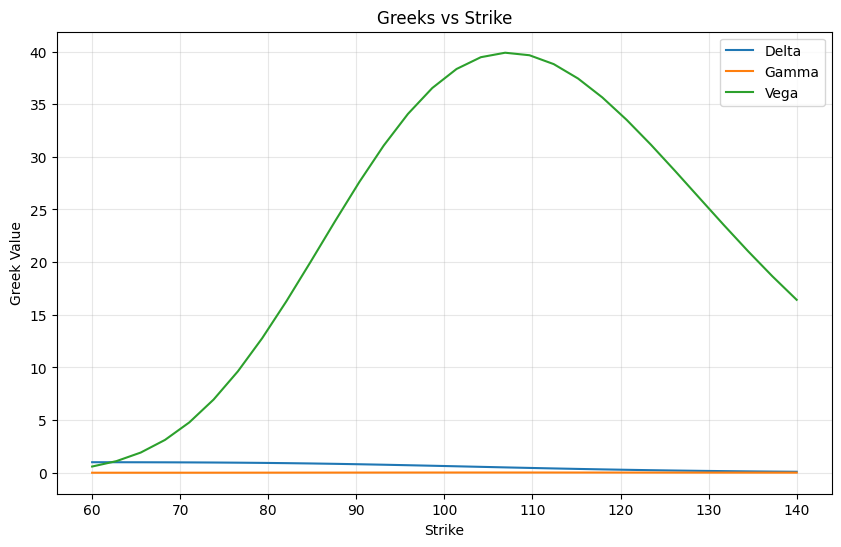

In [9]:
delta_values = [my_bs_delta(S0, strike, r, sigma, T) for strike in strike_values]
gamma_values = [my_bs_gamma(S0, strike, r, sigma, T) for strike in strike_values]
vega_values  = [my_bs_vega (S0, strike, r, sigma, T) for strike in strike_values]

plt.figure(figsize=(10,6))
plt.plot(strike_values, delta_values, label="Delta")
plt.plot(strike_values, gamma_values, label="Gamma")
plt.plot(strike_values, vega_values,  label="Vega")
plt.title("Greeks vs Strike")
plt.xlabel("Strike")
plt.ylabel("Greek Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

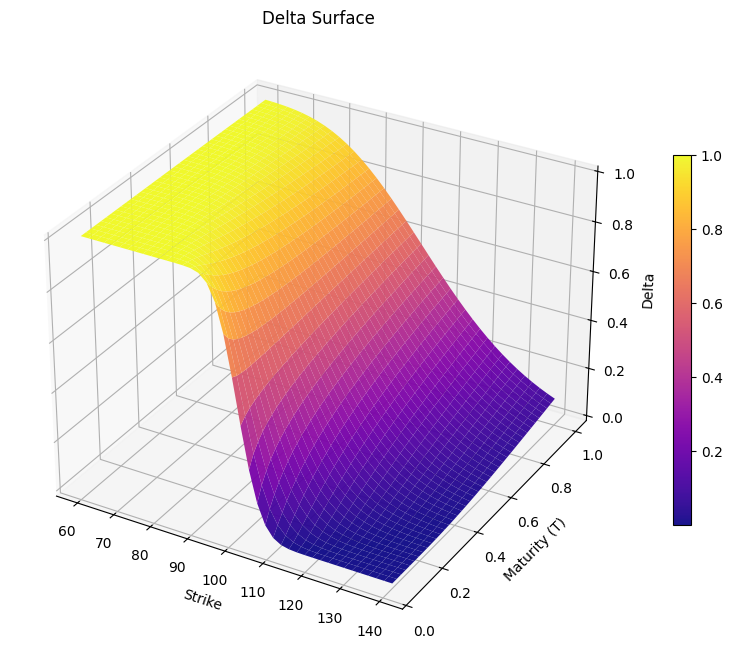

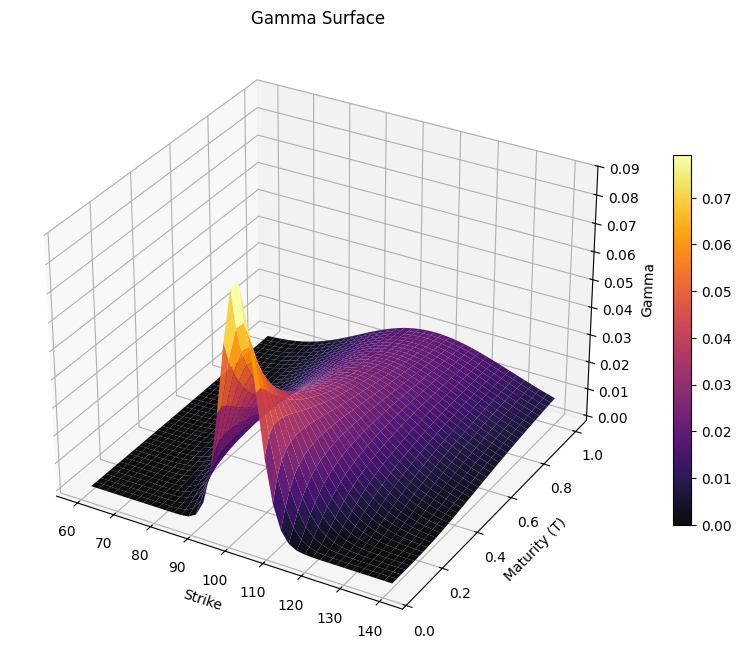

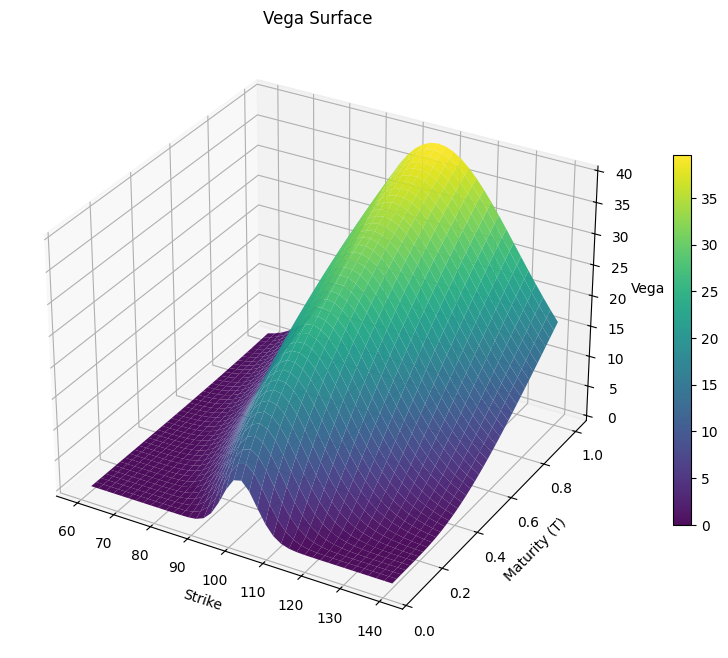

In [10]:
strike_mesh, tau_mesh = np.meshgrid(strike_grid, tau_grid)

delta_mesh = my_bs_delta(S0, strike_mesh, r, sigma, tau_mesh)
gamma_mesh = my_bs_gamma(S0, strike_mesh, r, sigma, tau_mesh)
vega_mesh  = my_bs_vega (S0, strike_mesh, r, sigma, tau_mesh)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(strike_mesh, tau_mesh, delta_mesh, cmap="plasma", alpha=0.95)
fig.colorbar(surface, shrink=0.6)
ax.set_title("Delta Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (T)")
ax.set_zlabel("Delta")
plt.show()

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(strike_mesh, tau_mesh, gamma_mesh, cmap="inferno", alpha=0.95)
fig.colorbar(surface, shrink=0.6)
ax.set_title("Gamma Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (T)")
ax.set_zlabel("Gamma")
plt.show()

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(strike_mesh, tau_mesh, vega_mesh, cmap="viridis", alpha=0.95)
fig.colorbar(surface, shrink=0.6)
ax.set_title("Vega Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (T)")
ax.set_zlabel("Vega")
plt.show()